# Problem Title - Scratch Mode
Issue: #<issue-number>

## 1. Setup and Imports
Use only NumPy and pandas for scratch work; do not use ML libraries unless the issue explicitly allows them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

## 2. Load and Inspect Data
Load dataset.csv and validate shape, columns, and missing values before training.

In [2]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. Preprocessing
Prepare features and target explicitly, including any normalization or encoding steps.

In [7]:
# Handle invalid zeros
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols:
    df[col] = df[col].replace(0, df[col].median())

# Split
X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values.reshape(-1,1)

# Train-test split
def train_test_split(X, y, test_size=0.2):
    np.random.seed(42)
    idx = np.random.permutation(len(X))
    split = int(len(X)*(1-test_size))
    return X[idx[:split]], X[idx[split:]], y[idx[:split]], y[idx[split:]]

X_train, X_test, y_train, y_test = train_test_split(X, y)

# Standardize
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean)/(std+1e-9)
X_test = (X_test - mean)/(std+1e-9)

# Add bias
X_train = np.hstack([np.ones((X_train.shape[0],1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0],1)), X_test])

## 4. Algorithm Implementation
Implement core model logic from scratch and keep helper functions readable and testable.

In [8]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def loss(y, y_pred):
    return -np.mean(y*np.log(y_pred+1e-9) + (1-y)*np.log(1-y_pred+1e-9))

def predict(X, w):
    probs = sigmoid(X @ w)
    return (probs >= 0.5).astype(int), probs

## 5. Training
Train your scratch implementation and track learning behavior across iterations.

In [10]:
def train_full_batch(X, y, lr=0.01, epochs=1000):
    w = np.zeros((X.shape[1],1))
    losses = []

    start = time.time()

    for i in range(epochs):
        y_pred = sigmoid(X @ w)
        l = loss(y, y_pred)
        losses.append(l)

        grad = (X.T @ (y_pred - y))/len(y)
        w -= lr * grad

    runtime = time.time() - start
    return w, losses, runtime

In [11]:
def train_mini_batch(X, y, lr=0.05, epochs=1000, batch_size=32, decay=0.001):
    w = np.zeros((X.shape[1],1))
    losses = []

    start = time.time()

    for epoch in range(epochs):
        lr_epoch = lr / (1 + decay*epoch)

        idx = np.random.permutation(len(X))
        X_shuff = X[idx]
        y_shuff = y[idx]

        for i in range(0, len(X), batch_size):
            X_batch = X_shuff[i:i+batch_size]
            y_batch = y_shuff[i:i+batch_size]

            y_pred = sigmoid(X_batch @ w)
            grad = (X_batch.T @ (y_pred - y_batch))/len(y_batch)

            w -= lr_epoch * grad

        # Track loss per epoch
        y_pred_full = sigmoid(X @ w)
        losses.append(loss(y, y_pred_full))

    runtime = time.time() - start
    return w, losses, runtime

In [12]:
w_full, loss_full, time_full = train_full_batch(X_train, y_train)
w_mini, loss_mini, time_mini = train_mini_batch(X_train, y_train)

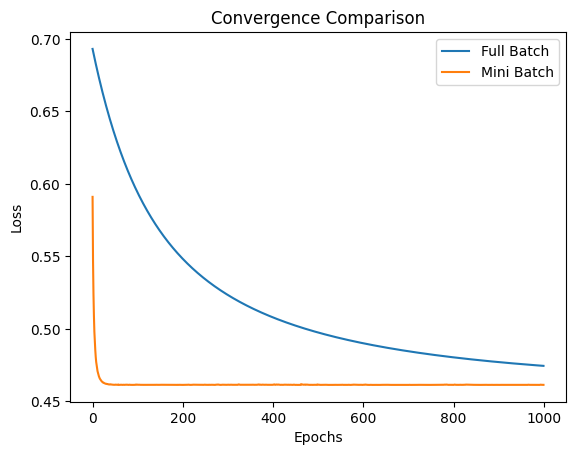

In [13]:
plt.plot(loss_full, label="Full Batch")
plt.plot(loss_mini, label="Mini Batch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence Comparison")
plt.legend()
plt.show()

## 6. Evaluation
Report the correct metric clearly and compare achieved value with target threshold.

In [14]:
def accuracy(y, y_pred):
    return np.mean(y == y_pred)

def f1(y, y_pred):
    tp = np.sum((y==1)&(y_pred==1))
    fp = np.sum((y==0)&(y_pred==1))
    fn = np.sum((y==1)&(y_pred==0))
    p = tp/(tp+fp+1e-9)
    r = tp/(tp+fn+1e-9)
    return 2*p*r/(p+r+1e-9)

In [15]:
pred_full, _ = predict(X_test, w_full)
pred_mini, _ = predict(X_test, w_mini)

print("Full Batch Accuracy:", accuracy(y_test, pred_full))
print("Mini Batch Accuracy:", accuracy(y_test, pred_mini))

print("Full Batch F1:", f1(y_test, pred_full))
print("Mini Batch F1:", f1(y_test, pred_mini))

print("Runtime Full:", time_full)
print("Runtime Mini:", time_mini)

Full Batch Accuracy: 0.7402597402597403
Mini Batch Accuracy: 0.7532467532467533
Full Batch F1: 0.615384614879438
Mini Batch F1: 0.6122448974635568
Runtime Full: 0.1684877872467041
Runtime Mini: 0.44432854652404785


## 7. Summary
Answer only these scratch-training questions:
1. Which core steps did you implement from scratch (math + code)?
2. How did your training behavior change over iterations (loss/metric trend), and what explains it?
3. What have you learned from implementing and evaluating this model from scratch in this notebook?

##Ans.1
Sigmoid activation function

Binary cross-entropy loss

Gradient computation for weights

Full-batch gradient descent

Mini-batch gradient descent

Learning rate decay schedule

Prediction using thresholding

##Ans.2
Loss decreased over iterations for both methods, showing learning

Mini-batch showed faster initial convergence but slight fluctuations

Learning rate decay stabilized training in later epochs

Final loss was comparable or slightly better than full-batch

Fluctuations are due to stochastic updates in mini-batch training

##Ans.3
Understood how mini-batch updates affect convergence speed and stability

Learned that learning rate decay improves training stability over time

Observed trade-off between faster convergence (mini-batch) and smoother updates (full-batch)

Gained deeper insight into gradient-based optimization and hyperparameter impact